In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [2]:
from model.metrics import logloss,evaluate_binary_classifier
from model.gradients import logloss_sigmoid_grad
from model.utils import *
from model.activations import sigmoid
import matplotlib.pyplot as plt

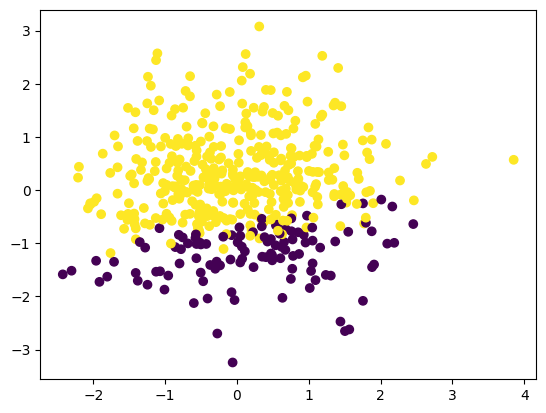

In [3]:
# Sample Code for generating datasets
size = 500
dim=2
noise_bound = 0.2

seed = 42
np.random.seed(seed)

X,y,W = generate_linear_dataset(size,dim,noise_bound=noise_bound,is_reg=False)
plt.scatter(X[:,1],X[:,2],c=y)

In [4]:
# loading data
loaded_data_A = np.load(f'data/logistic_data/logistic_data_A.npz')
loaded_data_B = np.load(f'data/logistic_data/logistic_data_B.npz')
loaded_data_C = np.load(f'data/logistic_data/logistic_data_C.npz')
loaded_data_D = np.load(f'data/logistic_data/logistic_data_D.npz')

dataset_A = {
    'X': loaded_data_A['X_data'],
    'y': loaded_data_A['y_data'],
    'W': loaded_data_A['W_data']
}

dataset_B = {
    'X': loaded_data_B['X_data'],
    'y': loaded_data_B['y_data'],
    'W': loaded_data_B['W_data']
}

dataset_C = {
    'X': loaded_data_C['X_data'],
    'y': loaded_data_C['y_data'],
    'W': loaded_data_C['W_data']
}

dataset_D = {
    'X': loaded_data_D['X_data'],
    'y': loaded_data_D['y_data'],
    'W': loaded_data_D['W_data']
}

# Show the size of data
print(f'X_A size : {dataset_A['X'].shape}, y_A size : {dataset_A['y'].shape}')
print(f'X_B size : {dataset_B['X'].shape}, y_B size : {dataset_B['y'].shape}')
print(f'X_C size : {dataset_C['X'].shape}, y_C size : {dataset_C['y'].shape}')
print(f'X_D size : {dataset_D['X'].shape}, y_D size : {dataset_D['y'].shape}')

# Make sure size and dim correct.
size = X.shape[0]
dim = X.shape[1]-1
print(f'X_A size : {dataset_A['X'].shape[0]}, dim_A : {dataset_A['X'].shape[1]-1}')
print(f'X_B size : {dataset_B['X'].shape[0]}, dim_B : {dataset_B['X'].shape[1]-1}')
print(f'X_C size : {dataset_C['X'].shape[0]}, dim_C : {dataset_C['X'].shape[1]-1}')
print(f'X_D size : {dataset_D['X'].shape[0]}, dim_D : {dataset_D['X'].shape[1]-1}')

X_A size : (2000, 3), y_A size : (2000,)
X_B size : (2000, 3), y_B size : (2000,)
X_C size : (8000, 6), y_C size : (8000,)
X_D size : (8000, 6), y_D size : (8000,)
X_A size : 2000, dim_A : 2
X_B size : 2000, dim_B : 2
X_C size : 8000, dim_C : 5
X_D size : 8000, dim_D : 5


50. Training loss: 0.42788681156341524, Val loss:0.4289337233194825
100. Training loss: 0.3186543688258759, Val loss:0.330744022589277
150. Training loss: 0.2756136848389012, Val loss:0.2918366320362445
200. Training loss: 0.2515647449518196, Val loss:0.27001137334938924
250. Training loss: 0.23586370599134487, Val loss:0.2557354638551537
300. Training loss: 0.2246778376496635, Val loss:0.24556151612210972
350. Training loss: 0.21624915555159713, Val loss:0.2379013150251245
400. Training loss: 0.20964409595419928, Val loss:0.23190816484103668
450. Training loss: 0.20431563313153664, Val loss:0.2270843249497499
500. Training loss: 0.19991967899618934, Val loss:0.22311586759002253


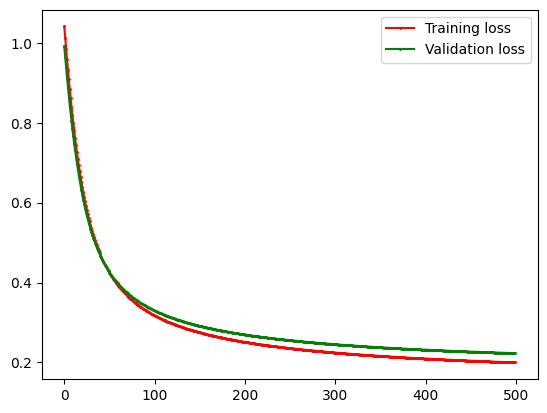

50. Training loss: 0.745459919917563, Val loss:0.7289685925005063
100. Training loss: 0.6684052041410407, Val loss:0.6557916620079434
150. Training loss: 0.60597131430406, Val loss:0.5968876243482448
200. Training loss: 0.5555295112853988, Val loss:0.549603760496019
250. Training loss: 0.5146553927944149, Val loss:0.5115124405275371
300. Training loss: 0.48129087814211324, Val loss:0.48057462242897986
350. Training loss: 0.4537813804466345, Val loss:0.4551703908054428
400. Training loss: 0.4308398665504119, Val loss:0.4340540530785389
450. Training loss: 0.4114822647561788, Val loss:0.41628271608980655
500. Training loss: 0.39496076529806007, Val loss:0.4011459118872098


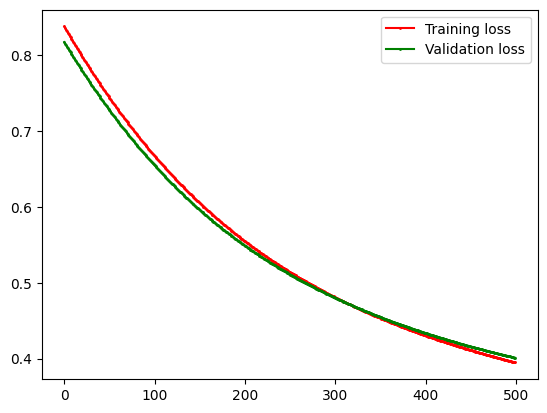

50. Training loss: 0.7093169445425764, Val loss:0.7045797723436771
100. Training loss: 0.7014838993048842, Val loss:0.6969548519437974
150. Training loss: 0.6938374304922718, Val loss:0.6895152134152447
200. Training loss: 0.6863731929864687, Val loss:0.6822564955015082
250. Training loss: 0.6790868552162503, Val loss:0.6751743498609324
300. Training loss: 0.6719741079220394, Val loss:0.6682644500316822
350. Training loss: 0.665030672285564, Val loss:0.6615224997485935
400. Training loss: 0.6582523074176521, Val loss:0.6549442406047219
450. Training loss: 0.6516348172040537, Val loss:0.6485254590573621
500. Training loss: 0.6451740565153343, Val loss:0.6422619927845884


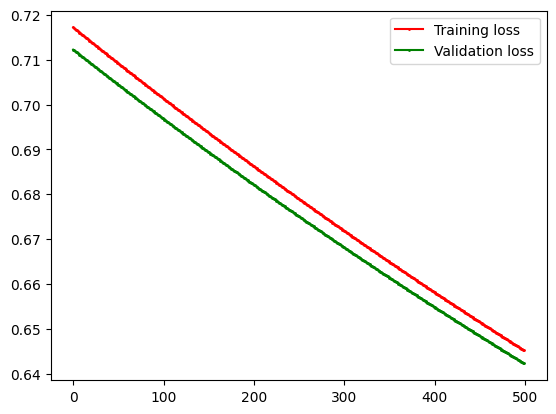

50. Training loss: 0.5113614195190571, Val loss:0.5089404988112158
100. Training loss: 0.4382995818888869, Val loss:0.43888007608316004
150. Training loss: 0.4162170529324693, Val loss:0.41731105316940165
200. Training loss: 0.40679853183641457, Val loss:0.4079679814594369
250. Training loss: 0.40208423537706584, Val loss:0.40321727810133356
300. Training loss: 0.39950208790948916, Val loss:0.40056794791793565
350. Training loss: 0.39800492636871254, Val loss:0.39899840617327637
400. Training loss: 0.39710260922977403, Val loss:0.3980275546395183
450. Training loss: 0.39654357211659447, Val loss:0.39740697144370885
500. Training loss: 0.3961900831700136, Val loss:0.3969997014318208


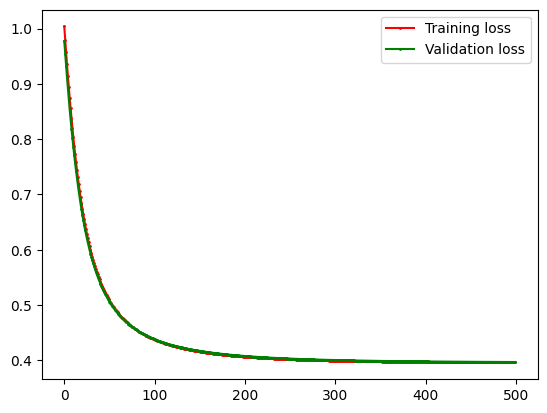

50. Training loss: 0.7922913365126665, Val loss:0.7885861470597196
100. Training loss: 0.7247683863367727, Val loss:0.7219425795440924
150. Training loss: 0.6700478376407373, Val loss:0.6680396806915438
200. Training loss: 0.6260388036094078, Val loss:0.6247705573267739
250. Training loss: 0.5907202304457236, Val loss:0.5900994995348492
300. Training loss: 0.5623067981950859, Val loss:0.5622342880310198
350. Training loss: 0.5393157125219787, Val loss:0.5396942324478768
400. Training loss: 0.5205641599935484, Val loss:0.5213052410651213
450. Training loss: 0.5051312496540745, Val loss:0.5061584225684078
500. Training loss: 0.49230891612933697, Val loss:0.49355835737675735


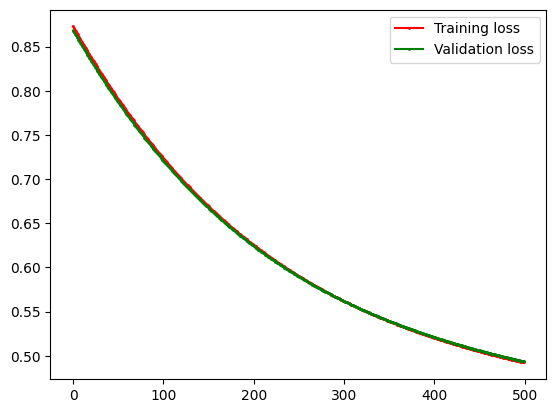

50. Training loss: 1.0461339228132378, Val loss:1.0429069961715882
100. Training loss: 1.033628710141578, Val loss:1.0304608153056551
150. Training loss: 1.0213270290740197, Val loss:1.018216592564593
200. Training loss: 1.0092290812138494, Val loss:1.0061746061376504
250. Training loss: 0.9973349305564397, Val loss:0.9943349961281973
300. Training loss: 0.9856445019477855, Val loss:0.9826977627845551
350. Training loss: 0.9741575799839779, Val loss:0.9712627651785581
400. Training loss: 0.9628738083664568, Val loss:0.9600297203477701
450. Training loss: 0.9517926897247271, Val loss:0.9489982029140714
500. Training loss: 0.9409135859148586, Val loss:0.9381676451878771


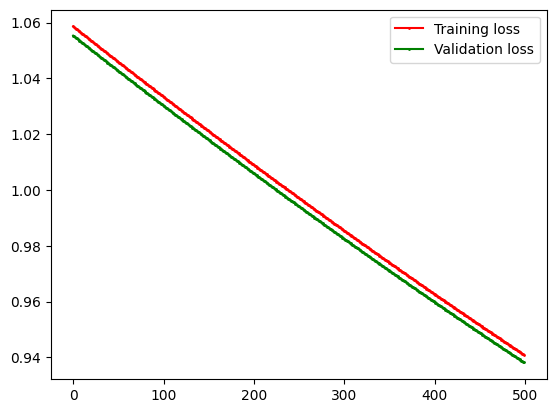

50. Training loss: 0.31789958495404463, Val loss:0.33536583645687706
100. Training loss: 0.257573701736161, Val loss:0.2757328365439687
150. Training loss: 0.22569120576589113, Val loss:0.24377553096279012
200. Training loss: 0.2049488594240531, Val loss:0.2228256287094638
250. Training loss: 0.18997862717029362, Val loss:0.20762186740493585
300. Training loss: 0.1784813662950277, Val loss:0.1958912858373861
350. Training loss: 0.16927500392397227, Val loss:0.1864595961023793
400. Training loss: 0.16167741390296791, Val loss:0.178647054679649
450. Training loss: 0.15526237283284144, Val loss:0.17202795657071182
500. Training loss: 0.1497475273350122, Val loss:0.16631974222261905


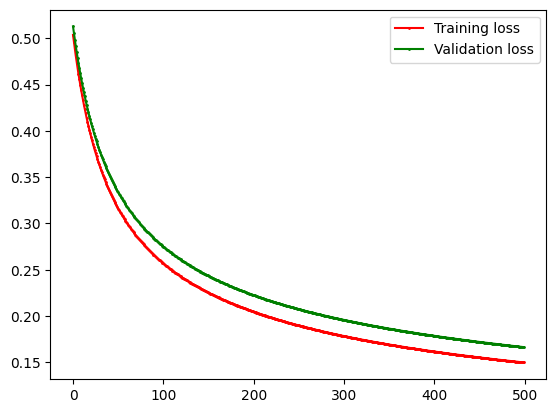

50. Training loss: 0.43682802697191603, Val loss:0.4460543870856757
100. Training loss: 0.4132148003726737, Val loss:0.4236899478748013
150. Training loss: 0.3932080661666527, Val loss:0.40472287855699063
200. Training loss: 0.37605132863978535, Val loss:0.3884370509874577
250. Training loss: 0.36117278255796115, Val loss:0.3742928390401497
300. Training loss: 0.3481368389539953, Val loss:0.36188007971877345
350. Training loss: 0.33660847139533656, Val loss:0.3508837928354824
400. Training loss: 0.3263272837927156, Val loss:0.34105942547355783
450. Training loss: 0.31708869503349013, Val loss:0.33221498519523895
500. Training loss: 0.30873024927590703, Val loss:0.32419808993968424


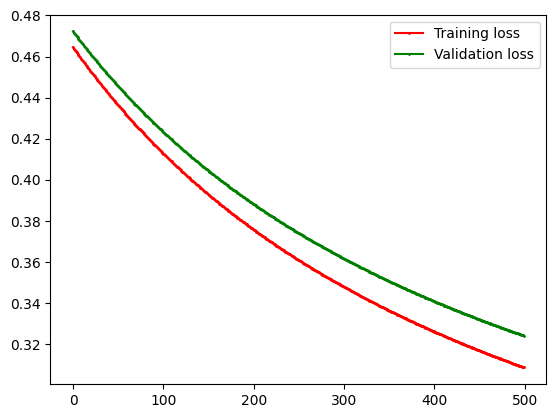

50. Training loss: 0.4759879581537255, Val loss:0.48401361090171735
100. Training loss: 0.47266405256373634, Val loss:0.4808292814884624
150. Training loss: 0.4694031186028309, Val loss:0.4777055438925141
200. Training loss: 0.46620363211853455, Val loss:0.47464091899389854
250. Training loss: 0.4630641062690556, Val loss:0.47163396424970383
300. Training loss: 0.45998309090043055, Val loss:0.468683273082104
350. Training loss: 0.4569591719058218, Val loss:0.4657874742466637
400. Training loss: 0.45399097056996185, Val loss:0.4629452311842671
450. Training loss: 0.45107714290150913, Val loss:0.4601552413597492
500. Training loss: 0.4482163789558715, Val loss:0.4574162355900553


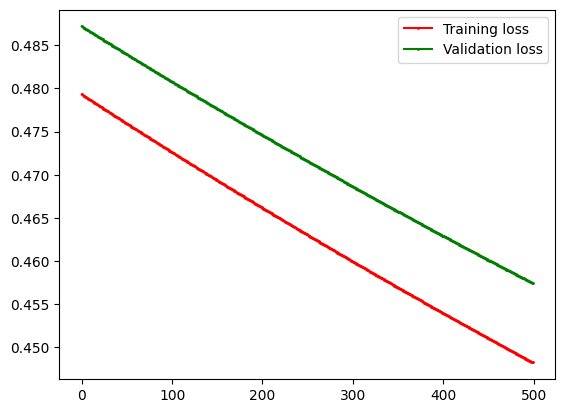

50. Training loss: 0.3382429213204896, Val loss:0.3507315744001963
100. Training loss: 0.28219026247354617, Val loss:0.29947875295160686
150. Training loss: 0.2541842838162694, Val loss:0.27323054928118523
200. Training loss: 0.2366454911788376, Val loss:0.25647159837236144
250. Training loss: 0.2243822688837282, Val loss:0.24458568345925585
300. Training loss: 0.2152326009736699, Val loss:0.23562514867516499
350. Training loss: 0.20810425748743483, Val loss:0.22859083517078913
400. Training loss: 0.20237494488143676, Val loss:0.22290495073752106
450. Training loss: 0.19765990750818538, Val loss:0.21820549750488985
500. Training loss: 0.1937066697998742, Val loss:0.21425226121054025


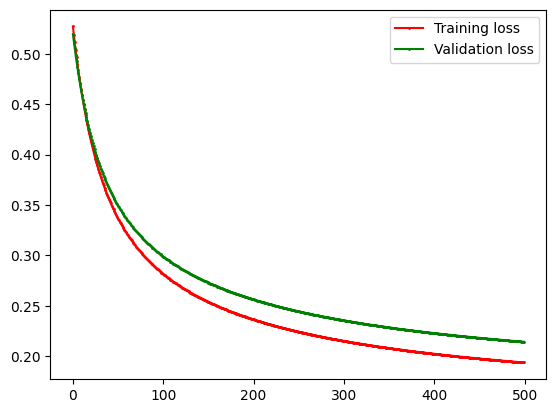

50. Training loss: 0.4612052062408482, Val loss:0.4579245945982821
100. Training loss: 0.4336084516337094, Val loss:0.4327500108389436
150. Training loss: 0.41026084674700874, Val loss:0.41149371195490214
200. Training loss: 0.39041942188943707, Val loss:0.3934672123562832
250. Training loss: 0.37346807926656833, Val loss:0.37810064991556674
300. Training loss: 0.35890078035676226, Val loss:0.36492624463249135
350. Training loss: 0.3463042741573631, Val loss:0.3535619169527631
400. Training loss: 0.3353420602930348, Val loss:0.3436963703509333
450. Training loss: 0.3257403428329455, Val loss:0.3350761557685193
500. Training loss: 0.3172761678735834, Val loss:0.3274947928479018


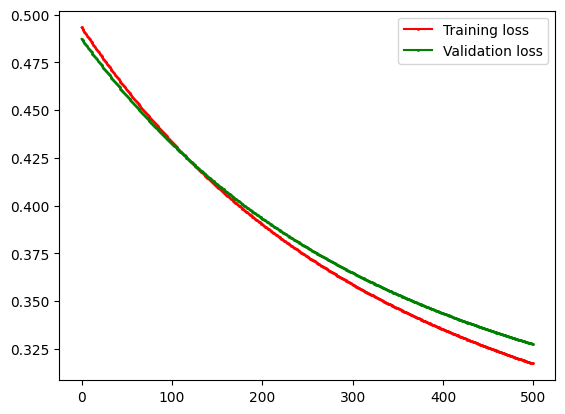

50. Training loss: 0.5875410006348476, Val loss:0.5801544390997344
100. Training loss: 0.5822358090076256, Val loss:0.5752792278304272
150. Training loss: 0.5770424238803853, Val loss:0.5705078094701762
200. Training loss: 0.5719583851998575, Val loss:0.5658378655278705
250. Training loss: 0.5669812633087679, Val loss:0.561267107427705
300. Training loss: 0.562108660602904, Val loss:0.55679327795811
350. Training loss: 0.5573382130247019, Val loss:0.5524141525755178
400. Training loss: 0.5526675913980673, Val loss:0.5481275405676698
450. Training loss: 0.5480945026097401, Val loss:0.5439312860814736
500. Training loss: 0.5436166906429859, Val loss:0.5398232690206799


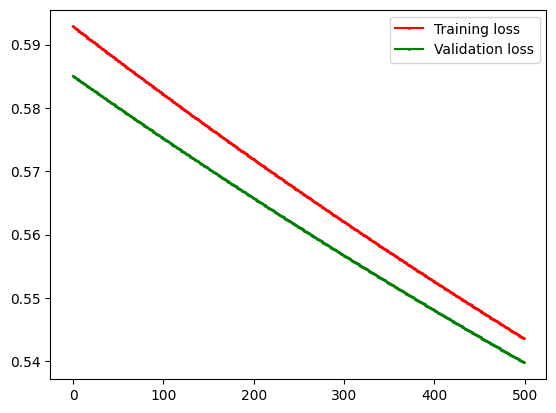

In [5]:
# Train the model
from model.linear_model import LinearModel

seed = 42 # do not change the seed
np.random.seed(seed)

# Setting loss function, gradient, and activation function.
loss_fn = logloss
act_fn = sigmoid
grad_fn = logloss_sigmoid_grad

# Split dataset to train dataset and validation dataset
X_train,y_train,X_val,y_val = get_train_val(X,y)

dataset_list = [dataset_A, dataset_B, dataset_C, dataset_D]

for dataset in dataset_list:
    X_train, y_train, X_val, y_val = get_train_val(dataset['X'],dataset['y'])
    dataset['X_train'] = X_train
    dataset['y_train'] = y_train
    dataset['X_val'] = X_val    
    dataset['y_val'] = y_val

# Setting model and starting training
#model = LinearModel(dim,False,loss_fn,grad_fn,act_fn)
#model.fit(X_train,y_train,lr=0.01,n_iteration=500,val_ratio=0.2)

lr_list = [0.1, 0.01, 0.001]

for dataset in dataset_list:
    for lr in lr_list:
        model = LinearModel((dataset['X'].shape[1]-1), False, loss_fn, grad_fn, act_fn)
        model.fit(dataset['X_train'], dataset['y_train'], lr=lr, n_iteration=500, val_ratio=0.2)
        dataset[f'model_lr_{lr}'] = model


In [6]:
# Get the Prediction
#y_val_pred = model.predict(X_val)

for dataset in dataset_list:
    for lr in lr_list:
        dataset[f'y_val_pred_lr_{lr}'] = dataset[f'model_lr_{lr}'].predict(dataset['X_val'])

'''
print(dataset_A[f'y_val_pred_lr_0.1'])
print(dataset_A[f'y_val_pred_lr_0.01'])
print(dataset_A[f'y_val_pred_lr_0.001'])
'''

"\nprint(dataset_A[f'y_val_pred_lr_0.1'])\nprint(dataset_A[f'y_val_pred_lr_0.01'])\nprint(dataset_A[f'y_val_pred_lr_0.001'])\n"

Logistic Regression Evaluation, lr=0.1
Accuracy  : 0.9050
Precision : 0.9087
Recall    : 0.9171
F1-score  : 0.9128


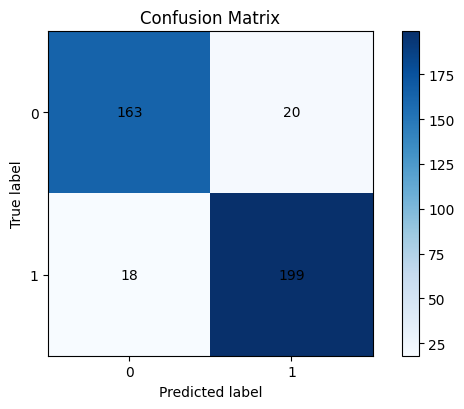

Logistic Regression Evaluation, lr=0.01
Accuracy  : 0.8775
Precision : 0.8784
Recall    : 0.8986
F1-score  : 0.8884


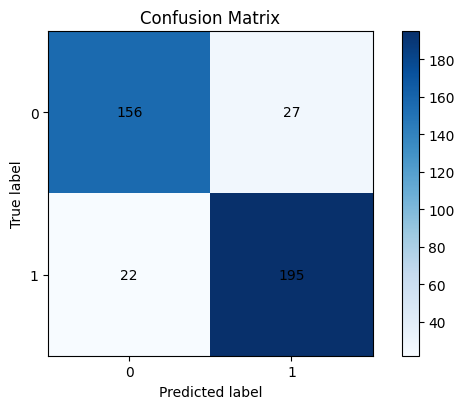

Logistic Regression Evaluation, lr=0.001
Accuracy  : 0.7000
Precision : 0.7156
Recall    : 0.7419
F1-score  : 0.7285


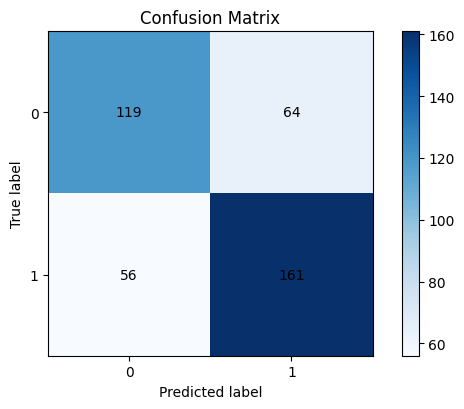

Logistic Regression Evaluation, lr=0.1
Accuracy  : 0.7800
Precision : 0.7793
Recall    : 0.8160
F1-score  : 0.7972


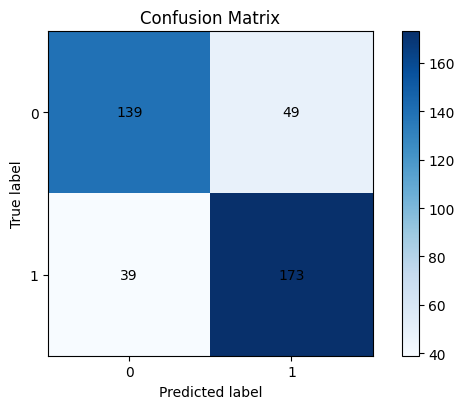

Logistic Regression Evaluation, lr=0.01
Accuracy  : 0.7750
Precision : 0.7699
Recall    : 0.8208
F1-score  : 0.7945


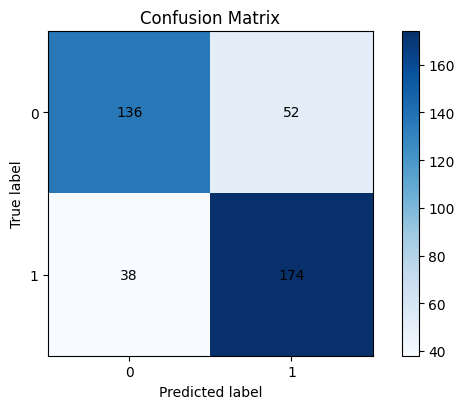

Logistic Regression Evaluation, lr=0.001
Accuracy  : 0.2700
Precision : 0.3095
Recall    : 0.3066
F1-score  : 0.3081


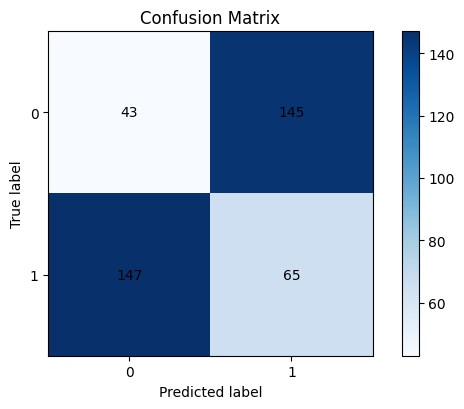

Logistic Regression Evaluation, lr=0.1
Accuracy  : 0.9762
Precision : 0.9852
Recall    : 0.9719
F1-score  : 0.9785


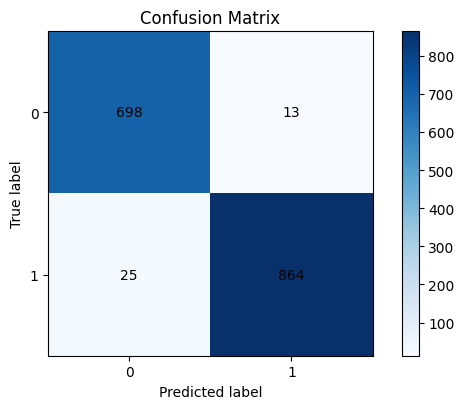

Logistic Regression Evaluation, lr=0.01
Accuracy  : 0.9600
Precision : 0.9780
Recall    : 0.9494
F1-score  : 0.9635


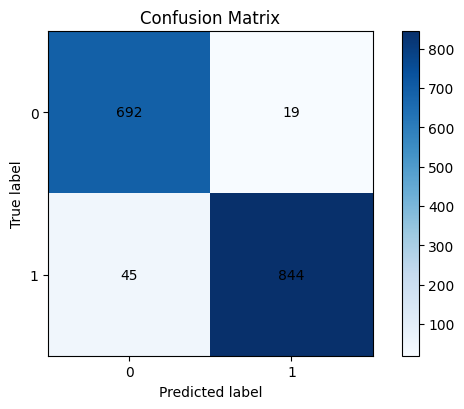

Logistic Regression Evaluation, lr=0.001
Accuracy  : 0.8125
Precision : 0.8561
Recall    : 0.7964
F1-score  : 0.8252


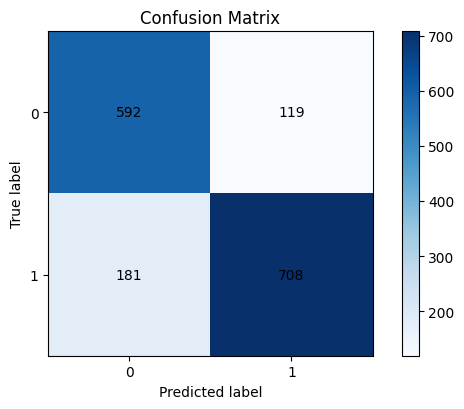

Logistic Regression Evaluation, lr=0.1
Accuracy  : 0.9225
Precision : 0.9330
Recall    : 0.9266
F1-score  : 0.9298


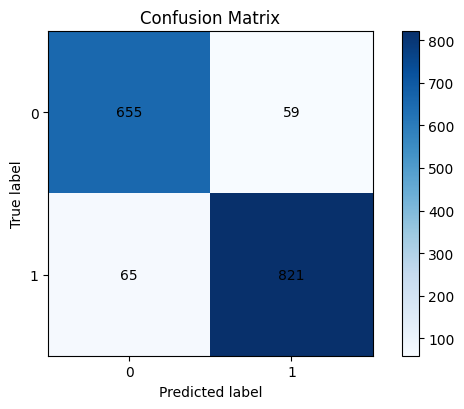

Logistic Regression Evaluation, lr=0.01
Accuracy  : 0.8994
Precision : 0.9230
Recall    : 0.8928
F1-score  : 0.9076


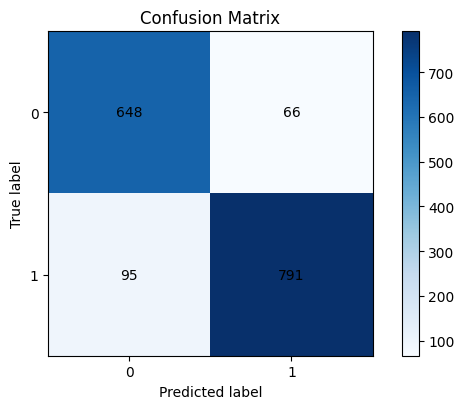

Logistic Regression Evaluation, lr=0.001
Accuracy  : 0.7225
Precision : 0.7756
Recall    : 0.7020
F1-score  : 0.7370


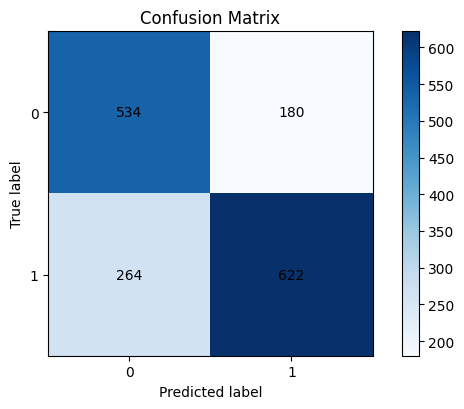

In [7]:
# Evaluation
# Please complete the evaluate_binary_classifier in the model/metrics.py by the sklearn package.
#evaluate_binary_classifier(y_true=y_val,y_pred=y_val_pred,title='Logistic Regression Evaluation')

for dataset in dataset_list:
    for lr in lr_list:
        evaluate_binary_classifier(y_true=dataset['y_val'], y_pred=dataset[f'y_val_pred_lr_{lr}'], title=f'Logistic Regression Evaluation, lr={lr}')

Plot validation set and decision boundary

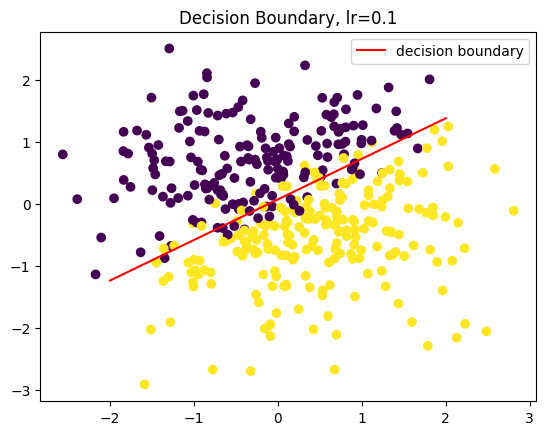

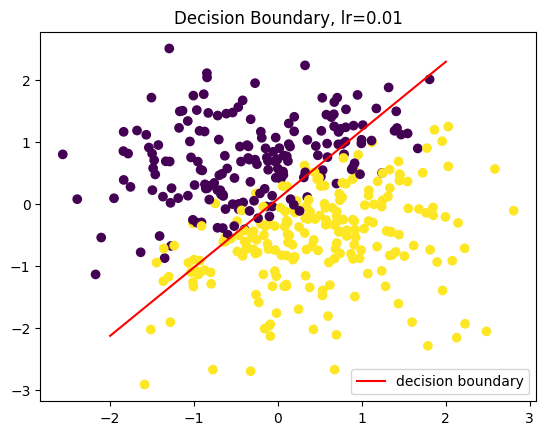

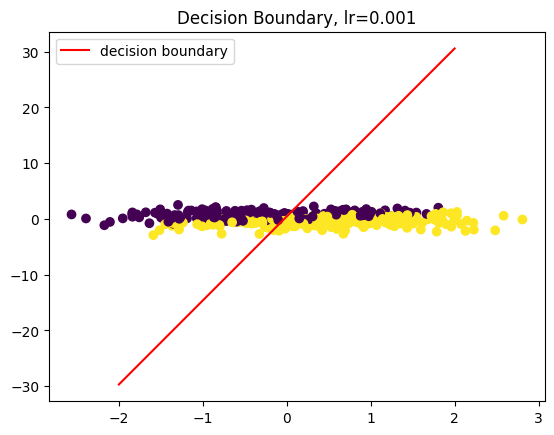

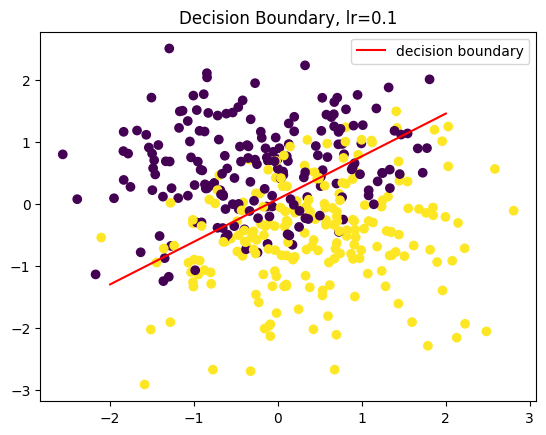

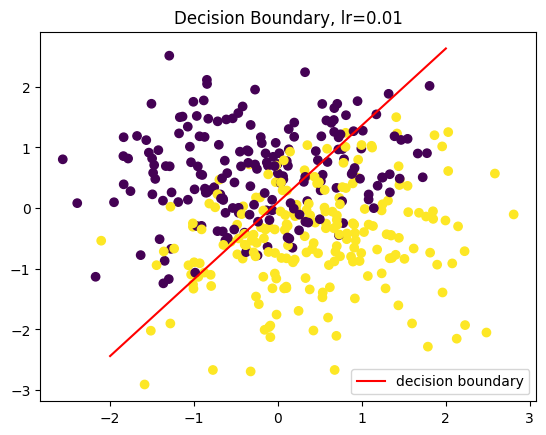

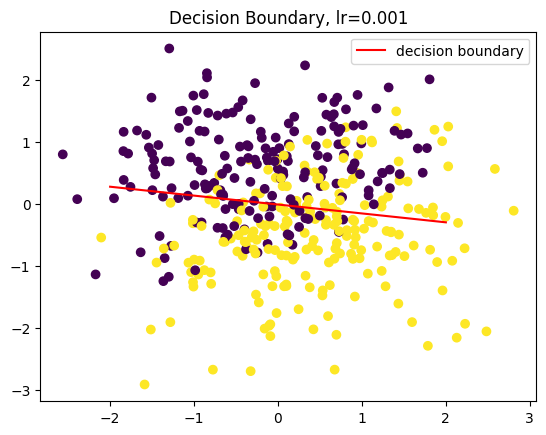

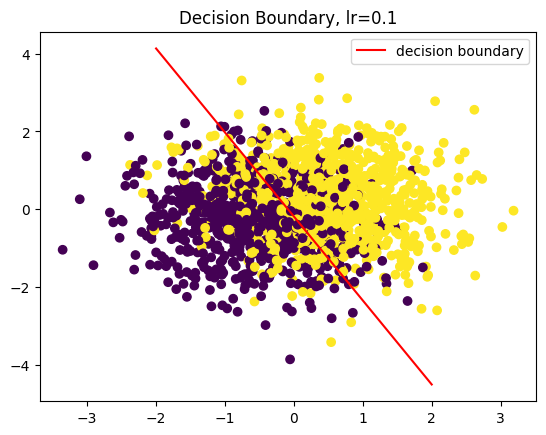

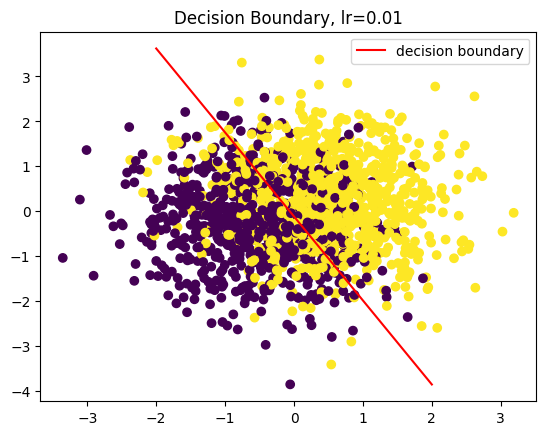

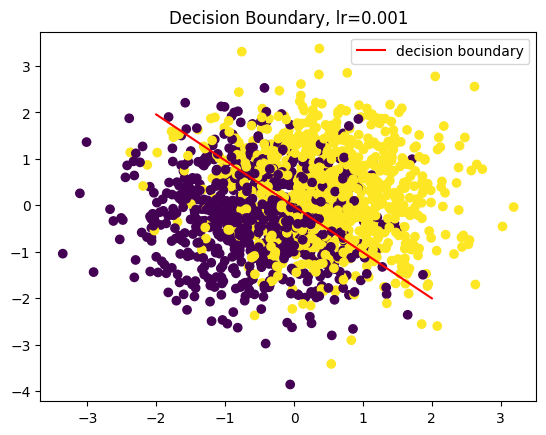

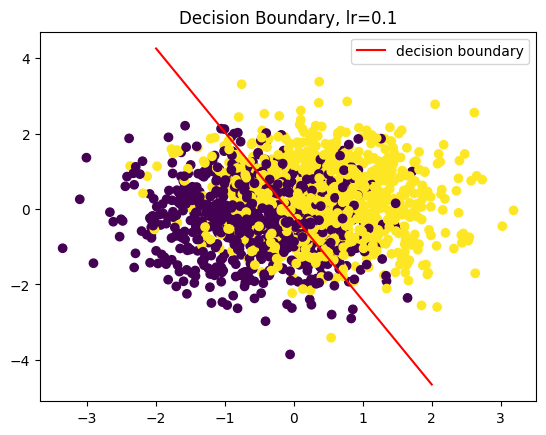

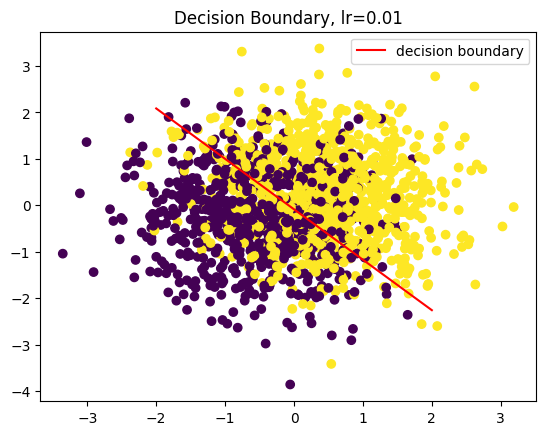

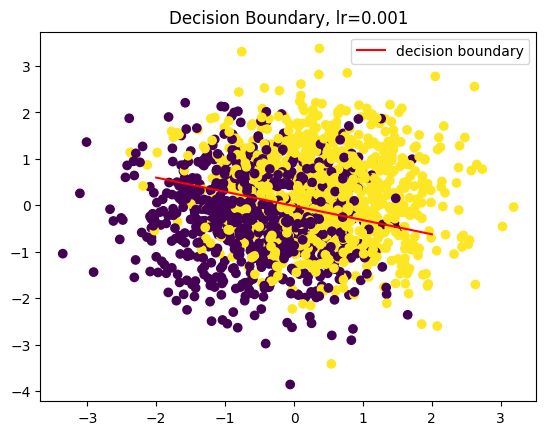

In [8]:
# Plot
'''
plt.scatter(X_val[:,1],X_val[:,2],c=y_val)

ex1 = np.linspace(-2, 2, 100)
ex2 = -(model.W[1] * ex1 + model.W[0]) / model.W[2]

plt.plot(ex1, ex2, color='r', label='decision boundary')
plt.legend()
plt.show()
'''
for dataset in dataset_list:
    for lr in lr_list:
        plt.scatter(dataset['X_val'][:,1],dataset['X_val'][:,2],c=dataset['y_val'])
        ex1 = np.linspace(-2, 2, 100)
        ex2 = -(dataset[f'model_lr_{lr}'].W[1] * ex1 + dataset[f'model_lr_{lr}'].W[0]) / dataset[f'model_lr_{lr}'].W[2]
        plt.plot(ex1, ex2, color='r', label='decision boundary')
        plt.legend()
        plt.title(f'Decision Boundary, lr={lr}')
        plt.show()

50. Training loss: 0.9371490132455621, Val loss:0.920451361670571
100. Training loss: 0.8204867109532401, Val loss:0.8074392493603433
150. Training loss: 0.7268122182150515, Val loss:0.7170756587217806
200. Training loss: 0.6526011774619322, Val loss:0.6458393607441677
250. Training loss: 0.593937071636111, Val loss:0.5898211834361305
300. Training loss: 0.5472503062049283, Val loss:0.545468817317287
350. Training loss: 0.509643540269119, Val loss:0.5099119148341431
400. Training loss: 0.4789098025665629, Val loss:0.4809760509084443
450. Training loss: 0.45341704689818263, Val loss:0.4570626814326296
500. Training loss: 0.431969068326321, Val loss:0.4370069461169625


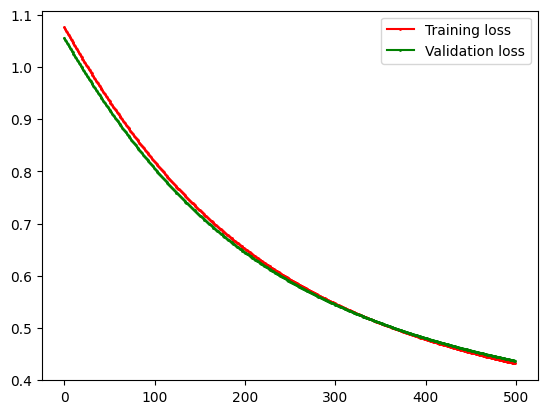

50. Training loss: 0.804613107610999, Val loss:0.7904000861020486
100. Training loss: 0.7145851541914074, Val loss:0.7038985823444441
150. Training loss: 0.6429821819176709, Val loss:0.6354577246155891
200. Training loss: 0.5861475097887328, Val loss:0.5814291216628013
250. Training loss: 0.5407569839053863, Val loss:0.5385065048825896
300. Training loss: 0.5040957471048262, Val loss:0.5040039118144474
350. Training loss: 0.4740772679147086, Val loss:0.4758704988595799
400. Training loss: 0.4491451314425589, Val loss:0.45258696886753536
450. Training loss: 0.42815025532427403, Val loss:0.43303903911721664
500. Training loss: 0.4102431416290756, Val loss:0.4164079168829947
550. Training loss: 0.39479083894552264, Val loss:0.40208683146248747
600. Training loss: 0.3813164727115507, Val loss:0.3896208290145126
650. Training loss: 0.36945622927505745, Val loss:0.3786642950343211
700. Training loss: 0.3589289523673873, Val loss:0.36895114356364206
750. Training loss: 0.34951459787126565, Va

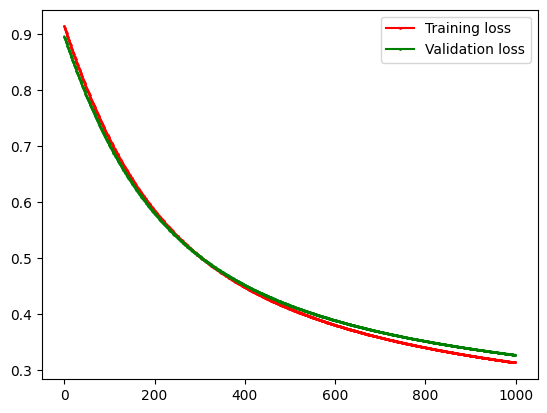

50. Training loss: 0.7455521168603744, Val loss:0.7335772329347025
100. Training loss: 0.6675809530023831, Val loss:0.6588985578055767
150. Training loss: 0.6056921155303174, Val loss:0.5999458282934382
200. Training loss: 0.5564034713176007, Val loss:0.5532493031001184
250. Training loss: 0.5167708075428304, Val loss:0.5158887362848974
300. Training loss: 0.4844868754173984, Val loss:0.4855899713822754
350. Training loss: 0.4578146032073677, Val loss:0.4606526790966468
400. Training loss: 0.43546789998501756, Val loss:0.4398265522092464
450. Training loss: 0.4164969187308401, Val loss:0.42219401471915347
500. Training loss: 0.40019613363686146, Val loss:0.4070773944783105
550. Training loss: 0.38603620940867217, Val loss:0.39397082809011125
600. Training loss: 0.37361517941482736, Val loss:0.38249189353350566
650. Training loss: 0.3626238743749736, Val loss:0.3723476197562669
700. Training loss: 0.352821451241945, Val loss:0.363310584252667
750. Training loss: 0.3440179703788259, Val 

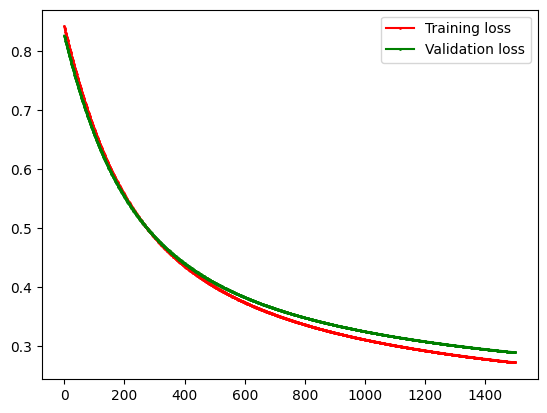

50. Training loss: 0.6365477409766113, Val loss:0.6350320928583068
100. Training loss: 0.5993918240589473, Val loss:0.5984644874506235
150. Training loss: 0.569622807189407, Val loss:0.5692023012651102
200. Training loss: 0.5456070010957073, Val loss:0.5456117677777096
250. Training loss: 0.5260577937563982, Val loss:0.5264121905229662
300. Training loss: 0.5099854648872127, Val loss:0.510623004030664
350. Training loss: 0.4966368776117168, Val loss:0.49750116492040136
400. Training loss: 0.48544026803141244, Val loss:0.48648454624392734
450. Training loss: 0.4759602382274329, Val loss:0.4771462794571303
500. Training loss: 0.46786313270235036, Val loss:0.4691599396170073


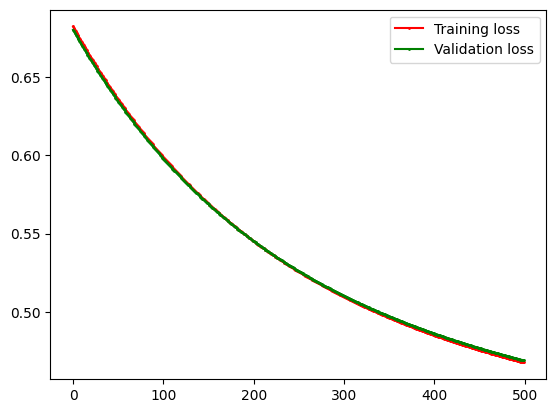

50. Training loss: 0.8122670359469849, Val loss:0.8092473891737576
100. Training loss: 0.7434911050366162, Val loss:0.7412749309125034
150. Training loss: 0.6863835288747829, Val loss:0.6849772662566329
200. Training loss: 0.6394774877652724, Val loss:0.6388484553988049
250. Training loss: 0.6012199633753509, Val loss:0.6013006203556304
300. Training loss: 0.5701141839089802, Val loss:0.570812013844983
350. Training loss: 0.544814411678205, Val loss:0.5460250739636604
400. Training loss: 0.5241713737811109, Val loss:0.5257910214261421
450. Training loss: 0.5072391260820195, Val loss:0.5091729512756282
500. Training loss: 0.4932582556776737, Val loss:0.49542473225105327
550. Training loss: 0.48162840609112967, Val loss:0.4839602635080116
600. Training loss: 0.4718787951790949, Val loss:0.47432209306509937
650. Training loss: 0.4636412968066799, Val loss:0.46615366022040855
700. Training loss: 0.4566278269414895, Val loss:0.4591764813133524
750. Training loss: 0.4506122131180927, Val los

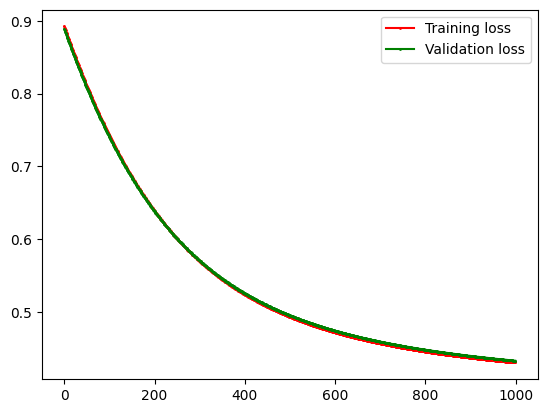

50. Training loss: 0.8557842737609433, Val loss:0.8521658407556932
100. Training loss: 0.7797270657048084, Val loss:0.7769232516955897
150. Training loss: 0.7162063386693156, Val loss:0.7142351785306162
200. Training loss: 0.6638321681909145, Val loss:0.6626749695618035
250. Training loss: 0.6210370105753421, Val loss:0.6206391016256041
300. Training loss: 0.5862431673709427, Val loss:0.5865205802673131
350. Training loss: 0.5579879441164416, Val loss:0.5588390358654715
400. Training loss: 0.5349951978817806, Val loss:0.5363135979813886
450. Training loss: 0.5161996430791163, Val loss:0.5178846742281642
500. Training loss: 0.5007388324731243, Val loss:0.5027016769500914
550. Training loss: 0.48792814451877076, Val loss:0.49009417176163994
600. Training loss: 0.47723016416166414, Val loss:0.4795387333812976
650. Training loss: 0.4682251013703354, Val loss:0.4706280793293235
700. Training loss: 0.46058521664428387, Val loss:0.4630450425779423
750. Training loss: 0.4540540099447952, Val l

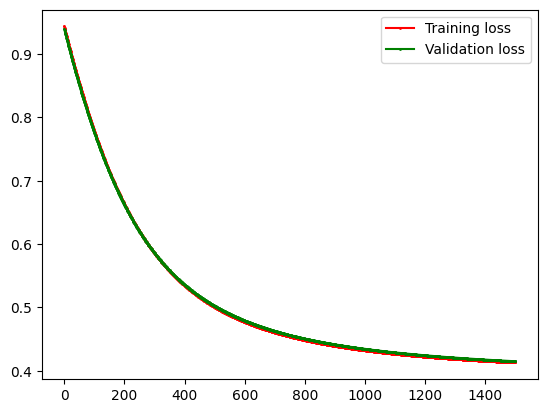

50. Training loss: 0.4890189326900093, Val loss:0.4954163813511524
100. Training loss: 0.45510312163486777, Val loss:0.46337291162515354
150. Training loss: 0.42696802176282667, Val loss:0.43675762998086454
200. Training loss: 0.40340406306039167, Val loss:0.4144297818975059
250. Training loss: 0.3834654409250101, Val loss:0.39550206722293196
300. Training loss: 0.36641874340804703, Val loss:0.3792884301909512
350. Training loss: 0.351696423036261, Val loss:0.3652585017544179
400. Training loss: 0.3388583472686565, Val loss:0.3530008803345817
450. Training loss: 0.32756153885845685, Val loss:0.3421946744535245
500. Training loss: 0.31753698712340095, Val loss:0.33258787880067037


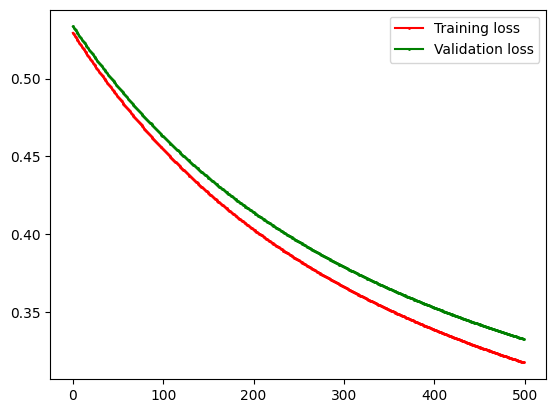

50. Training loss: 0.48306717276885414, Val loss:0.49084884819897895
100. Training loss: 0.45078032059072937, Val loss:0.45993211214674956
150. Training loss: 0.42391314795350465, Val loss:0.43422226864419394
200. Training loss: 0.4013285737428955, Val loss:0.41261754428187947
250. Training loss: 0.38214266207266456, Val loss:0.3942642479913391
300. Training loss: 0.36567212488932693, Val loss:0.3785044727815864
350. Training loss: 0.35138898539678776, Val loss:0.36483115700397234
400. Training loss: 0.3388839693059763, Val loss:0.35285205607208203
450. Training loss: 0.3278380397011285, Val loss:0.34226191794533956
500. Training loss: 0.31800072984712624, Val loss:0.3328214233917703
550. Training loss: 0.3091738309034189, Val loss:0.3243414016347352
600. Training loss: 0.30119916385649487, Val loss:0.31667103791994056
650. Training loss: 0.2939494119345999, Val loss:0.3096890545213671
700. Training loss: 0.28732122656718423, Val loss:0.3032970908449878
750. Training loss: 0.2812300174

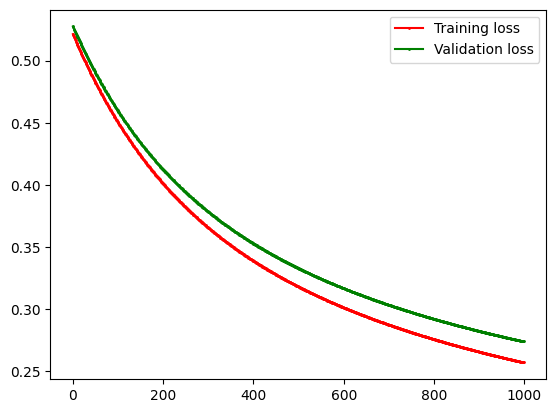

50. Training loss: 0.49094502044889426, Val loss:0.4953138093925352
100. Training loss: 0.45744062514846184, Val loss:0.463540400531165
150. Training loss: 0.4296369952959399, Val loss:0.4372070154800416
200. Training loss: 0.4063221931603154, Val loss:0.41514264105197957
250. Training loss: 0.38655821419019093, Val loss:0.3964458878603266
300. Training loss: 0.3696228681158249, Val loss:0.38042592481243565
350. Training loss: 0.35496012441648794, Val loss:0.3665527386762229
400. Training loss: 0.342140366142999, Val loss:0.3544178947171188
450. Training loss: 0.3308296958992244, Val loss:0.34370459197733083
500. Training loss: 0.3207666976331357, Val loss:0.3341651917948859
550. Training loss: 0.31174501843165653, Val loss:0.3256044788833688
600. Training loss: 0.3036003603900111, Val loss:0.3178672133214652
650. Training loss: 0.2962007606724518, Val loss:0.3108288551969001
700. Training loss: 0.2894393043468205, Val loss:0.304388623443858
750. Training loss: 0.2832286329191049, Val 

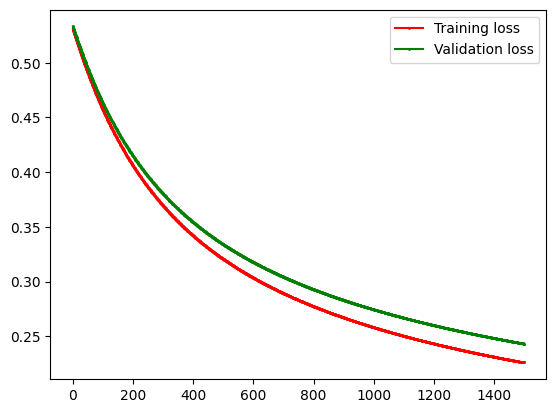

50. Training loss: 0.5355659243082143, Val loss:0.5395013141729175
100. Training loss: 0.4960699369900484, Val loss:0.5023069494090798
150. Training loss: 0.463040249167687, Val loss:0.47123251931054916
200. Training loss: 0.43534148521845156, Val loss:0.4451841798468477
250. Training loss: 0.4120117652194879, Val loss:0.42324233760599617
300. Training loss: 0.39225280880196656, Val loss:0.40465034784051407
350. Training loss: 0.3754115599235078, Val loss:0.38879329285342545
400. Training loss: 0.3609586487979117, Val loss:0.37517468898788076
450. Training loss: 0.3484671183454912, Val loss:0.36339483050715815
500. Training loss: 0.33759326135488216, Val loss:0.3531320871876898


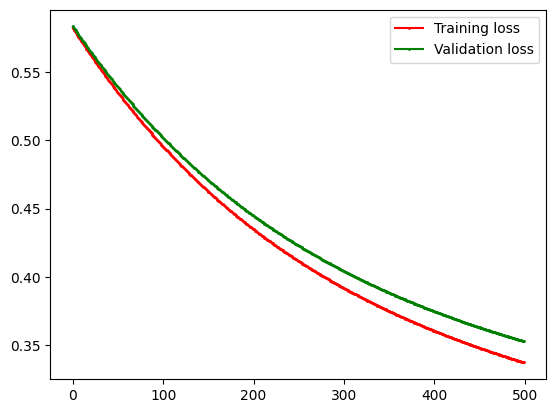

50. Training loss: 0.4178270858870864, Val loss:0.4289490166811364
100. Training loss: 0.3982125385118266, Val loss:0.4104723750966823
150. Training loss: 0.38155339102155394, Val loss:0.394768310868641
200. Training loss: 0.3672743638348211, Val loss:0.3812985593405112
250. Training loss: 0.3549247047272019, Val loss:0.369641221979016
300. Training loss: 0.34415054408513546, Val loss:0.3594647340835082
350. Training loss: 0.33467294102516554, Val loss:0.3505073879652049
400. Training loss: 0.32627082337646324, Val loss:0.3425614930119772
450. Training loss: 0.3187678842895224, Val loss:0.3354612228058332
500. Training loss: 0.3120225703025023, Val loss:0.3290733200668283
550. Training loss: 0.30592043955833287, Val loss:0.323289986771967
600. Training loss: 0.30036831938712527, Val loss:0.3180234339735382
650. Training loss: 0.2952898242865006, Val loss:0.3132016891563043
700. Training loss: 0.29062190191212206, Val loss:0.30876535674199274
750. Training loss: 0.2863121573489827, Val 

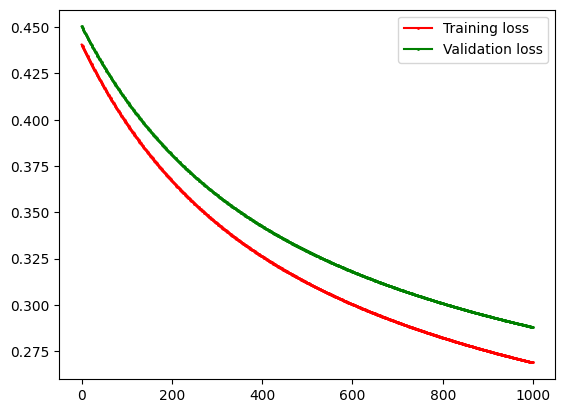

50. Training loss: 0.4772830917314902, Val loss:0.4809371193920195
100. Training loss: 0.44882516627553315, Val loss:0.45442384981584977
150. Training loss: 0.4251074497143453, Val loss:0.4323332856525769
200. Training loss: 0.4051502083982773, Val loss:0.41375234172975794
250. Training loss: 0.3881907902231836, Val loss:0.39797066147374494
300. Training loss: 0.3736373557307477, Val loss:0.38443641506633525
350. Training loss: 0.3610300715126872, Val loss:0.3727200947015311
400. Training loss: 0.3500102616789846, Val loss:0.36248603860357437
450. Training loss: 0.34029657242321903, Val loss:0.35347050282014875
500. Training loss: 0.3316668236718205, Val loss:0.34546495321139553
550. Training loss: 0.3239442820825098, Val loss:0.3383033913120869
600. Training loss: 0.3169872956055251, Val loss:0.33185274645857393
650. Training loss: 0.31068145501106137, Val loss:0.32600557952431275
700. Training loss: 0.3049336457963731, Val loss:0.3206745235514591
750. Training loss: 0.299667513103801

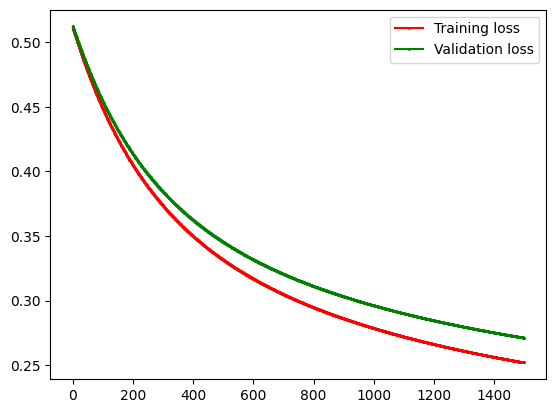

In [9]:
n_iterations_list = [500, 1000, 1500]
lr = 0.01

for dataset in dataset_list:
    for n_iteration in n_iterations_list:
        model = LinearModel((dataset['X'].shape[1]-1), False, loss_fn, grad_fn, act_fn)
        model.fit(dataset['X_train'], dataset['y_train'], lr=lr, n_iteration=n_iteration, val_ratio=0.2)
        dataset[f'model_n_iteration_{n_iteration}'] = model

Logistic Regression Evaluation, n_iterations=500
Accuracy  : 0.9025
Precision : 0.8938
Recall    : 0.9309
F1-score  : 0.9120


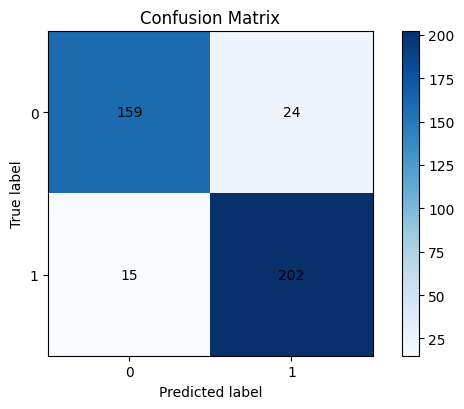

Logistic Regression Evaluation, n_iterations=1000
Accuracy  : 0.9050
Precision : 0.9124
Recall    : 0.9124
F1-score  : 0.9124


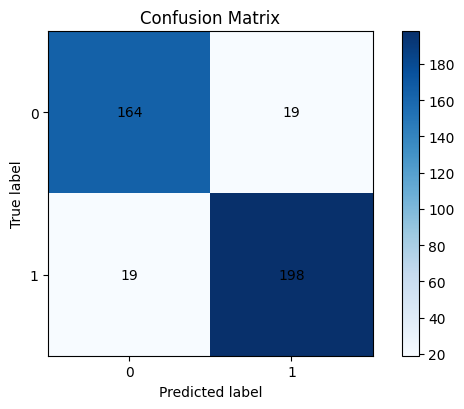

Logistic Regression Evaluation, n_iterations=1500
Accuracy  : 0.9025
Precision : 0.9083
Recall    : 0.9124
F1-score  : 0.9103


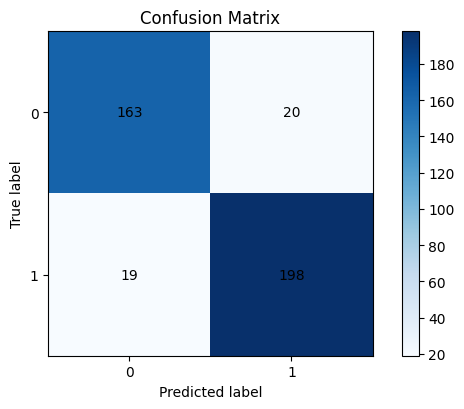

Logistic Regression Evaluation, n_iterations=500
Accuracy  : 0.7850
Precision : 0.7812
Recall    : 0.8255
F1-score  : 0.8028


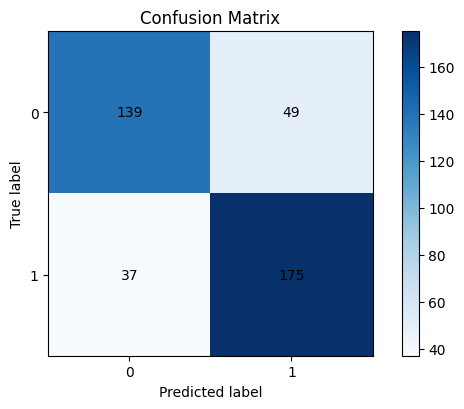

Logistic Regression Evaluation, n_iterations=1000
Accuracy  : 0.7875
Precision : 0.7822
Recall    : 0.8302
F1-score  : 0.8055


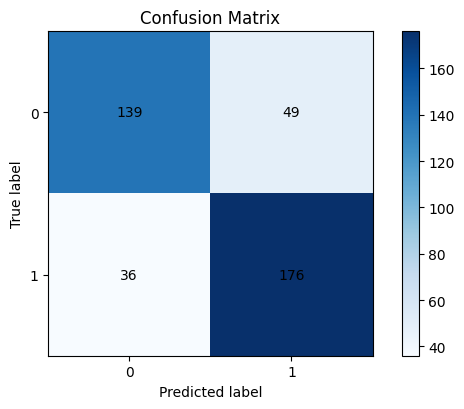

Logistic Regression Evaluation, n_iterations=1500
Accuracy  : 0.7750
Precision : 0.7773
Recall    : 0.8066
F1-score  : 0.7917


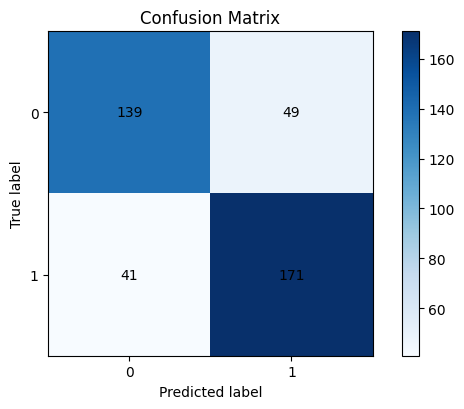

Logistic Regression Evaluation, n_iterations=500
Accuracy  : 0.9425
Precision : 0.9628
Recall    : 0.9325
F1-score  : 0.9474


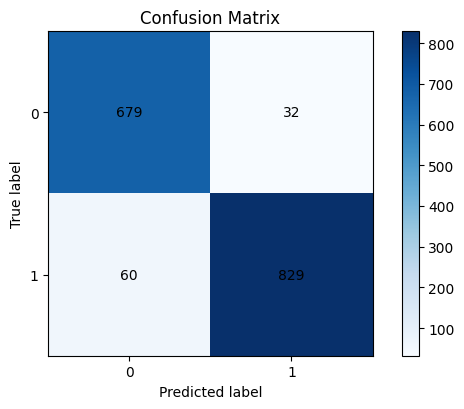

Logistic Regression Evaluation, n_iterations=1000
Accuracy  : 0.9744
Precision : 0.9874
Recall    : 0.9663
F1-score  : 0.9767


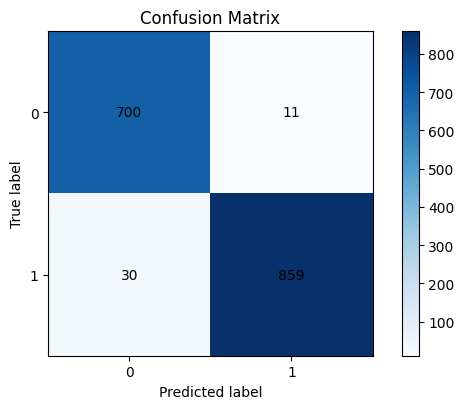

Logistic Regression Evaluation, n_iterations=1500
Accuracy  : 0.9800
Precision : 0.9897
Recall    : 0.9741
F1-score  : 0.9819


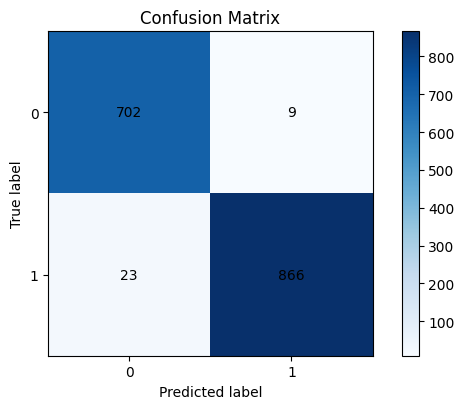

Logistic Regression Evaluation, n_iterations=500
Accuracy  : 0.8769
Precision : 0.8992
Recall    : 0.8758
F1-score  : 0.8874


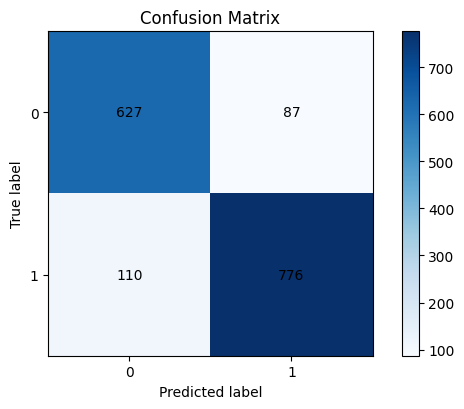

Logistic Regression Evaluation, n_iterations=1000
Accuracy  : 0.9213
Precision : 0.9338
Recall    : 0.9233
F1-score  : 0.9285


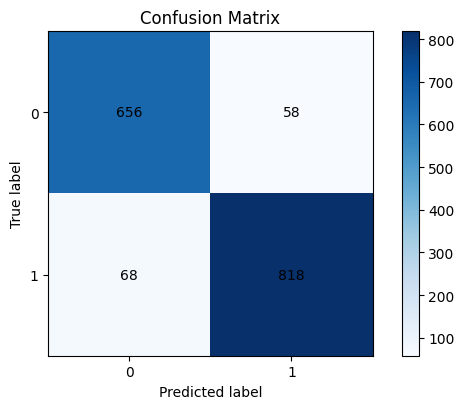

Logistic Regression Evaluation, n_iterations=1500
Accuracy  : 0.9244
Precision : 0.9381
Recall    : 0.9244
F1-score  : 0.9312


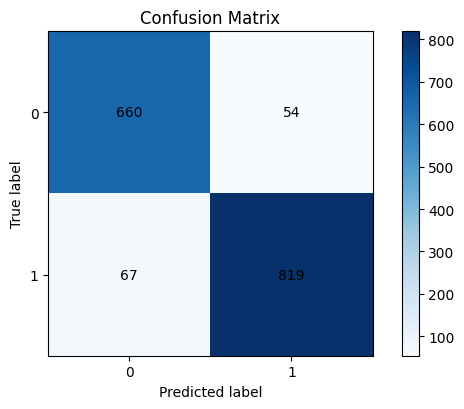

In [10]:
for dataset in dataset_list:
    for n_iteration in n_iterations_list:
        dataset[f'y_val_pred_n_iteration_{n_iteration}'] = dataset[f'model_n_iteration_{n_iteration}'].predict(dataset['X_val'])

for dataset in dataset_list:
    for n_iteration in n_iterations_list:
        evaluate_binary_classifier(y_true=dataset['y_val'], y_pred=dataset[f'y_val_pred_n_iteration_{n_iteration}'], title=f'Logistic Regression Evaluation, n_iterations={n_iteration}')